In [8]:
# importing processed datasets for ML
import pandas as pd

X_train_stress = pd.read_csv("ml_ready_data/X_train_stress.csv")
X_test_stress = pd.read_csv("ml_ready_data/X_test_stress.csv")
y_train_stress = pd.read_csv("ml_ready_data/y_train_stress.csv").squeeze("columns")
y_test_stress = pd.read_csv("ml_ready_data/y_test_stress.csv").squeeze("columns")

X_train_deflection = pd.read_csv("ml_ready_data/X_train_deflection.csv")
X_test_deflection = pd.read_csv("ml_ready_data/X_test_deflection.csv")
y_train_deflection = pd.read_csv("ml_ready_data/y_train_deflection.csv").squeeze("columns")
y_test_deflection = pd.read_csv("ml_ready_data/y_test_deflection.csv").squeeze("columns")

print("Stress model     -> Train:", X_train_stress.shape, " Test:", X_test_stress.shape)
print("Deflection model -> Train:", X_train_deflection.shape, " Test:", X_test_deflection.shape)


Stress model     -> Train: (64, 6)  Test: (17, 6)
Deflection model -> Train: (64, 6)  Test: (17, 6)


# Stress Model

In [9]:
from sklearn.ensemble import RandomForestRegressor

stress_model = RandomForestRegressor(n_estimators=100, random_state=42)
stress_model.fit(X_train_stress, y_train_stress)
print("Model trained.")

Model trained.


In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_stress_pa = stress_model.predict(X_test_stress)

# Convert to MPa for interpretable metrics/plots
y_test_mpa = y_test_stress / 1e6
y_pred_mpa = y_pred_stress_pa / 1e6

mae = mean_absolute_error(y_test_mpa, y_pred_mpa)
rmse = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mpa))
r2 = r2_score(y_test_mpa, y_pred_mpa)

print(f"MAE:  {mae:.3f} MPa")
print(f"RMSE: {rmse:.3f} MPa")
print(f"R²:   {r2:.4f}")

MAE:  1.747 MPa
RMSE: 2.234 MPa
R²:   0.9388


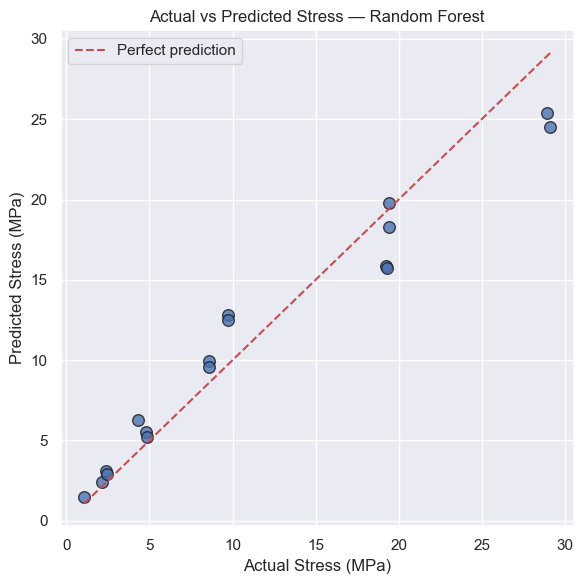

In [13]:
# used AI to refine plots
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_mpa, y_pred_mpa, s=70, alpha=0.8, edgecolor="k")
lims = [min(y_test_mpa.min(), y_pred_mpa.min()), max(y_test_mpa.max(), y_pred_mpa.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Stress (MPa)")
ax.set_ylabel("Predicted Stress (MPa)")
ax.set_title("Actual vs Predicted Stress — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

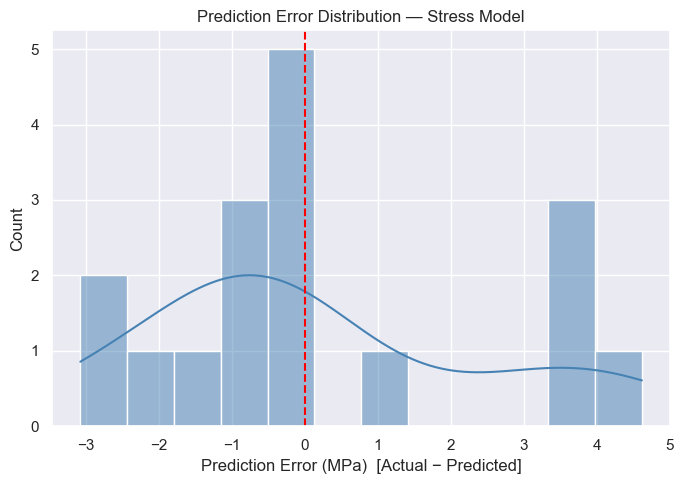

In [14]:
# Prediction error distribution
errors = y_test_mpa - y_pred_mpa

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(errors, kde=True, bins=12, color="steelblue", ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Prediction Error (MPa)  [Actual − Predicted]")
ax.set_title("Prediction Error Distribution — Stress Model")
plt.tight_layout()
plt.show()

# Deflection Model